# Human Action Classifier - Pretrained Model
**Schuldt et al. 2004. Recognizing Human Actions: A Local SVM Approach**

In [18]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import re
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from joblib import load

In [19]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device = "cpu"
print(device)

cpu


### 1. Data Loading

In [ ]:
K = 400 # 50
ACTIONS = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking" ]
action_to_id = {a: i for i, a in enumerate(ACTIONS)}
pattern = re.compile(r"person(?P<person>\d+)_(?P<action>[a-z]+)_d(?P<scene>\d)")

def index_data(root="data/transform"):
    samples = []
    for video in Path(root).glob("*.avi"):
        match = pattern.search(video.name)
        if match is None:
            continue
        samples.append({
            "path": video,
            "label": action_to_id[match.group("action")],
            "action": match.group("action"),
            "person": int(match.group("person")),
            "scene": int(match.group("scene")),
        })
    return samples

In [22]:
# Import all data
samples = index_data()
print("Total:", Counter(s["action"] for s in samples))

# Train/validation/test split (70-15-15)
train_samples = [s for s in samples if s["person"] <= 17]
val_samples = [s for s in samples if 17 < s["person"] <= 21]
test_samples = [s for s in samples if s["person"] > 21]
print("Train:", len(train_samples), "Validation:", len(val_samples), "Test:", len(test_samples))

Total: Counter({'boxing': 100, 'running': 100, 'handwaving': 100, 'walking': 100, 'jogging': 100, 'handclapping': 99})
Train: 407 Validation: 96 Test: 96


### 2. Data Processing
#### 2.1. Transform Video To Image Sequence

In [23]:
def load_video(path, resize=(160, 120)):
    cap = cv2.VideoCapture(str(path))
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = cv2.resize(frame, resize)
        frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    video = np.stack(frames)   # (T, H, W)
    return torch.from_numpy(video)

#### 2.2. Construct Gaussian Scale Space
$$L(· , \sigma^2, \tau^2) = f \times g(· , \sigma^2, \tau^2)$$

In [24]:
def gaussian_1d(kernel_size, sigma):
    x = torch.arange(kernel_size) - kernel_size // 2
    g = torch.exp(-(x ** 2) / (2 * (sigma ** 2)))
    return g / g.sum()

def gaussian_blur_3d(video, sigma, tau):
    # spatial blur
    g_xy = gaussian_1d(7, sigma)
    g_xy = g_xy[None, None, :, None] * g_xy[None, None, None, :]
    video = F.conv2d(video.unsqueeze(1), g_xy, padding=3).squeeze(1)

    # temporal blur
    g_t = gaussian_1d(7, tau)[None, None, :, None, None]
    video = F.conv3d(video.unsqueeze(0), g_t, padding=(3,0,0)).squeeze(0)

    return video

### 3. Feature Extraction
#### 3.1. Compute Second-moment Matrix From Spatio-temporal Gradients

$$\nabla L = (L_x, L_y, L_t)^T$$
$$\mu(·; \sigma^2, \tau^2) = g(·; s\sigma^2, s\tau^2) \times (\nabla L(\nabla L)^T)$$

In [25]:
def gradients_3d(L):
	Lx = L[:, :, 2:] - L[:, :, :-2]
	Ly = L[:, 2:, :] - L[:, :-2, :]
	Lt = L[2:, :, :] - L[:-2, :, :]

	T = min(Lx.shape[0], Ly.shape[0], Lt.shape[0])
	H = min(Lx.shape[1], Ly.shape[1], Lt.shape[1])
	W = min(Lx.shape[2], Ly.shape[2], Lt.shape[2])

	return Lx[:T, :H, :W], Ly[:T, :H, :W], Lt[:T, :H, :W]

def second_moment_matrix(Lx, Ly, Lt, sigma=2.0, tau=1.5):
    J_xx = Lx * Lx
    J_xy = Lx * Ly
    J_xt = Lx * Lt
    J_yy = Ly * Ly
    J_yt = Ly * Lt
    J_tt = Lt * Lt

    def smooth(x):
        return gaussian_blur_3d(x, sigma, tau)

    return smooth(J_xx), smooth(J_xy), smooth(J_xt), smooth(J_yy), smooth(J_yt), smooth(J_tt)

#### 3.2. Detect Interest Point Using Harris Response

$$H = det(\mu) - k * trace^3(\mu)$$

In [26]:
def harris_response(J, k=0.005):
    J_xx, J_xy, J_xt, J_yy, J_yt, J_tt = J

    det = (
        J_xx * (J_yy * J_tt - J_yt ** 2)
        - J_xy * (J_xy * J_tt - J_xt * J_yt)
        + J_xt * (J_xy * J_yt - J_xt * J_yy)
    )

    trace = J_xx + J_yy + J_tt
    return det - k * trace ** 3

def detect_interest_points(H, threshold_ratio=0.01):
    threshold = threshold_ratio * H.max()
    points = torch.nonzero(H > threshold)
    return points

#### 3.3. Extract Spatio-temporal Descriptors

$$\bold{l} = (L_x, L_y, L_t, L_{xx}, ..., L_{tttt})$$

In [27]:
def extract_jet(L, x, y, t, sigma, tau):
    # first order
    Lx = L[t, y, x+1] - L[t, y, x-1]
    Ly = L[t, y+1, x] - L[t, y-1, x]
    Lt = L[t+1, y, x] - L[t-1, y, x]

    # second order
    Lxx = L[t, y, x+1] - 2*L[t, y, x] + L[t, y, x-1]
    Lyy = L[t, y+1, x] - 2*L[t, y, x] + L[t, y-1, x]
    Ltt = L[t+1, y, x] - 2*L[t, y, x] + L[t-1, y, x]

    jet = torch.tensor([
        sigma * Lx, sigma * Ly, tau * Lt,
        sigma**2 * Lxx, sigma**2 * Lyy, tau**2 * Ltt
    ], device=L.device)

    return jet

def extract_descriptors(video, sigma=1.5, tau=1.0):
    L = gaussian_blur_3d(video, sigma, tau)
    Lx, Ly, Lt = gradients_3d(L)
    J = second_moment_matrix(Lx, Ly, Lt, 2*sigma, 2*tau)
    H = harris_response(J)

    points = detect_interest_points(H)
    desc = []

    for t, y, x in points:
        if (
            t > 1 and y > 1 and x > 1 and
            t < L.shape[0]-2 and
            y < L.shape[1]-2 and
            x < L.shape[2]-2
        ):
            desc.append(extract_jet(L, x, y, t, sigma, tau))

    if len(desc) == 0:
        return torch.empty((0, 6), device=device)

    return torch.stack(desc)

#### 3.4. Load Pretrained KMeans

In [28]:
print("Loading pretrained KMeans...")
kmeans = load("artifact/kmeans_K400_0.joblib")

Loading pretrained KMeans...


#### 3.5. Visualize Video as Histogram

In [29]:
def encode_video(video, kmeans, K):
    desc = extract_descriptors(video)

    if desc.numel() == 0:
        return torch.zeros(K)

    labels = kmeans.predict(desc.cpu().numpy())
    hist = np.bincount(labels, minlength=K).astype(np.float32)
    hist /= (hist.sum() + 1e-8)

    return torch.from_numpy(hist)

def visualize_histogram(hist, sample):
    plt.figure(figsize=(12, 4))
    plt.bar(range(K), hist.numpy())
    plt.title(f"Action: {sample['action']} | Person: {sample['person']} | Scene: {sample['scene']}")
    plt.xlabel("Visual Word Index")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"artifact/histogram_action{sample['action']}_person{sample['person']}_scene{sample['scene']}.png", dpi=150)
    plt.show()

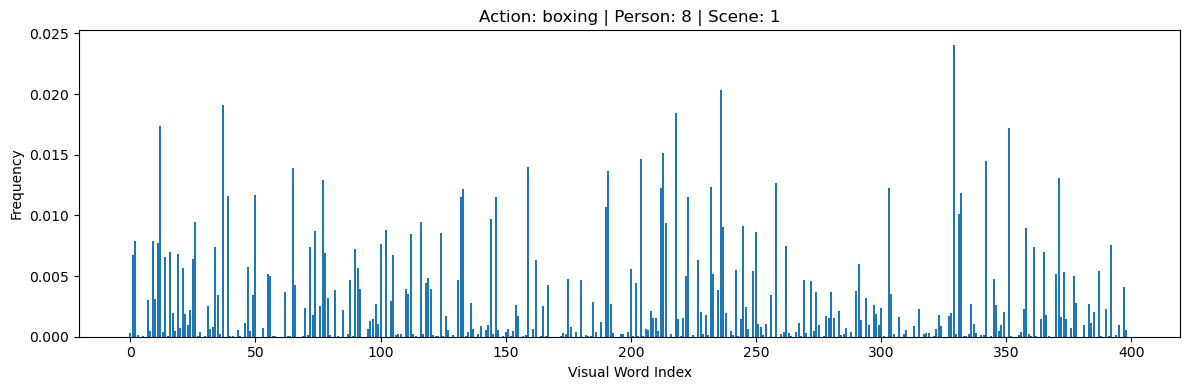

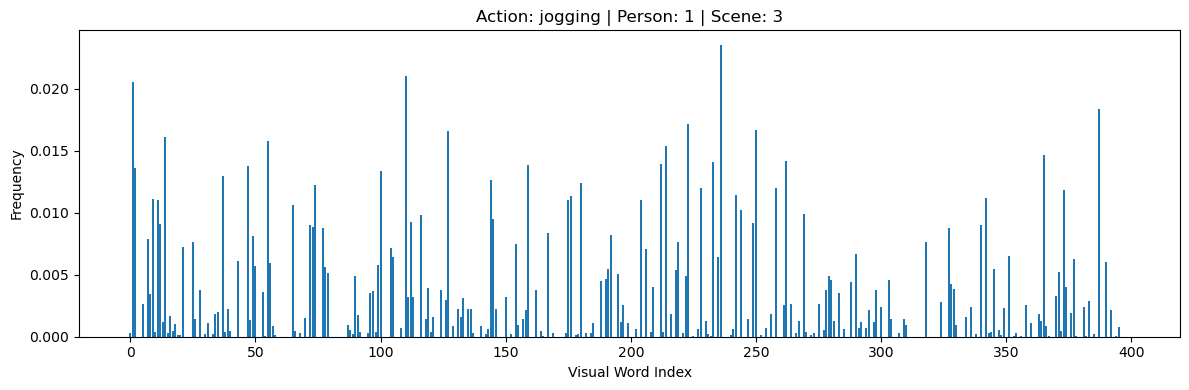

In [30]:
# Visualize 2 sample histogram
for i in [0, 26]:
	sample = train_samples[i]
	video = load_video(sample["path"])
	video = video.to(device)
	hist = encode_video(video, kmeans, K)
	visualize_histogram(hist, sample)

In [42]:
def visualize_descriptors_on_frame(video, sample, sigma=1.5, tau=1.0, num_frames=2):
    """Visualize interest points detected on video frames"""
    # Extract features to get interest points
    L = gaussian_blur_3d(video, sigma, tau)
    Lx, Ly, Lt = gradients_3d(L)
    J = second_moment_matrix(Lx, Ly, Lt, 2*sigma, 2*tau)
    H = harris_response(J)
    points = detect_interest_points(H)
    
    print(f"Total descriptors detected: {len(points)}")
    
    if len(points) == 0:
        print("No descriptors detected in this video")
        return
    
    # Visualize descriptors on selected frames
    fig, axes = plt.subplots(1, min(num_frames, 2), figsize=(14, 5))
    if num_frames == 1:
        axes = [axes]
    
    # Select frames to visualize (spread across video)
    frame_indices = np.linspace(1, video.shape[0]-10, num_frames, dtype=int)
    
    for ax_idx, frame_idx in enumerate(frame_indices):
        frame = video[frame_idx].numpy()
        frame_display = (frame * 255).astype(np.uint8)
        
        # Get descriptors on this frame
        frame_points = points[points[:, 0] == frame_idx]
        
        ax = axes[ax_idx] if num_frames > 1 else axes[0]
        ax.imshow(frame_display, cmap='gray')
        
        # Draw circles at interest points
        if len(frame_points) > 0:
            for _, y, x in frame_points:
                circle = plt.Circle((x, y), 3, color='red', fill=False, linewidth=2)
                ax.add_patch(circle)
        
        ax.set_title(f"Frame {frame_idx} ({len(frame_points)} descriptors)")
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f"artifact/descriptors_action{sample['action']}_person{sample['person']}_scene{sample['scene']}.png", dpi=150)
    plt.show()


Total descriptors detected: 138499


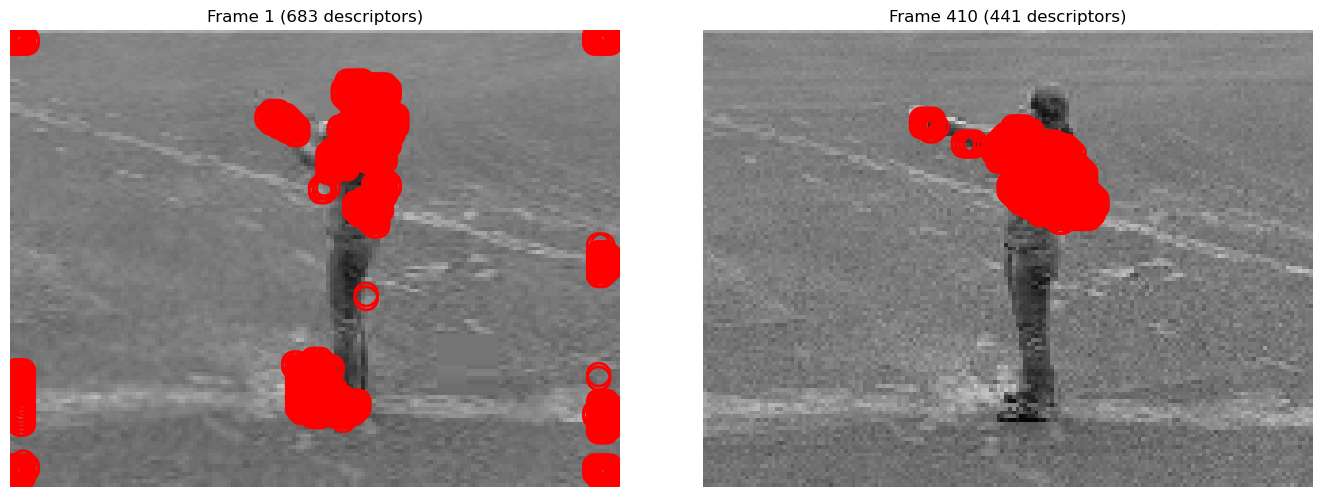

Total descriptors detected: 93961


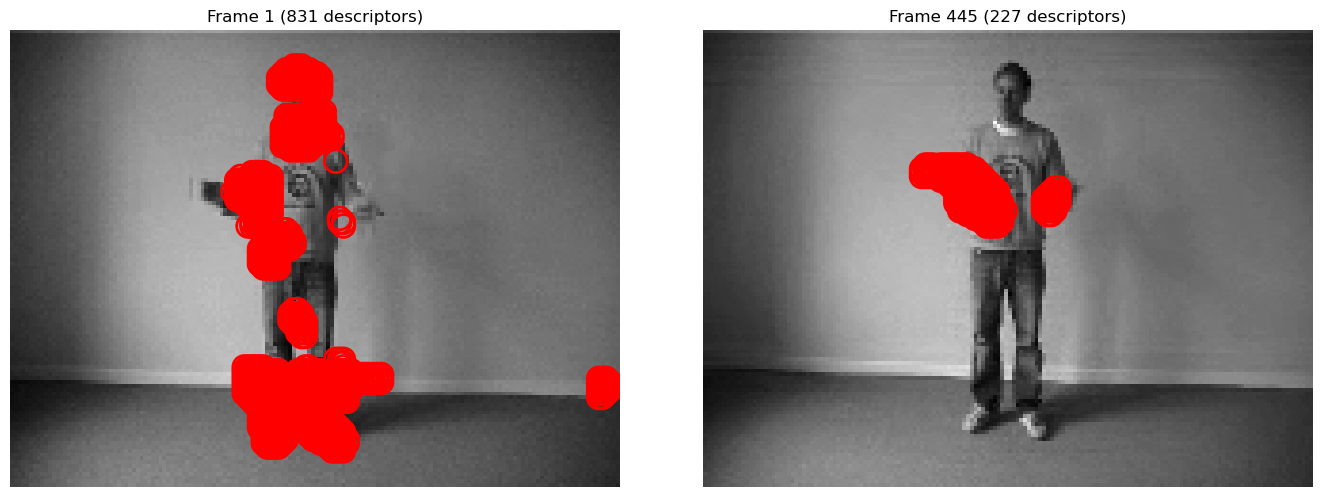

In [43]:
# Visualize 1-2 sample descriptors on video frames
for i in [0, 326]:
    sample = train_samples[i]
    video = load_video(sample["path"])
    video = video.to(device)
    visualize_descriptors_on_frame(video, sample, num_frames=2)


#### 3.6. Load Presaved Features

In [35]:
print("Loading presaved features...")
features = torch.load("artifact/kth_features_0.pt")
X_train = features["X_train"]
y_train = features["y_train"]
X_val = features["X_val"]
y_val = features["y_val"]
X_test = features["X_test"]
y_test = features["y_test"]

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape, "y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

Loading presaved features...
X_train shape: torch.Size([407, 400]) y_train shape: torch.Size([407])
X_val shape: torch.Size([96, 400]) y_val shape: torch.Size([96])
X_test shape: torch.Size([96, 400]) y_test shape: torch.Size([96])


### 4. Train Classifier

In [36]:
def train_svm(X, y):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.numpy())

    clf = LinearSVC(C=1.0, max_iter=5000)
    clf.fit(Xs, y.numpy())

    return clf, scaler

In [37]:
print("Training classifier...")
clf, scaler = train_svm(X_train, y_train)

Training classifier...


### 5. Model Evaluation

In [38]:
def evaluate(clf, scaler, X, y):
    Xs = scaler.transform(X.numpy())
    y_pred = clf.predict(Xs)

    acc = accuracy_score(y.numpy(), y_pred)
    cm = confusion_matrix(y.numpy(), y_pred)

    return acc, cm

In [39]:
print("---- Validation ----")
val_acc, _ = evaluate(clf, scaler, X_val, y_val)
print(f"Val accuracy: {val_acc*100:.2f}%")

---- Validation ----
Val accuracy: 79.17%


In [40]:
print("---- Test ----")
test_acc, cm = evaluate(clf, scaler, X_test, y_test)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(cm)

---- Test ----
Test accuracy: 71.88%
[[ 7  6  3  0  0  0]
 [ 1 14  0  1  0  0]
 [ 2  0 12  0  1  1]
 [ 0  0  1 13  2  0]
 [ 0  0  0  6  9  1]
 [ 0  1  0  1  0 14]]
